# <font color=#F90499>**Modelo Hackathonnn**</font>
***

## <font color=#05C0F3>**Introduccion al problema**</font>

### **Sector del negocio**

Atención al cliente / Marketing / Operaciones — empresas que recopilan opiniones de clientes (reseñas, comentarios en redes sociales, encuestas de satisfacción) y quieren entender rápidamente si el sentimiento es positivo, neutro o negativo.
***

### **Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso: Positivo / Neutro / Negativo o binario Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.
***

### **Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:

1. saber rápidamente si los clientes se están quejando o elogiando;

2. priorizar respuestas a comentarios negativos;

3. medir la satisfacción a lo largo del tiempo.

Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.
***

### **Validación de mercado**

Analizar si el sentimiento es útil para:

- acelerar la atención al cliente (identificar urgencias);

- monitorear campañas de marketing;

- comparar la imagen de la marca a lo largo del tiempo.

Incluso una solución simple (modelo básico) tiene valor: las pequeñas y medianas empresas utilizan herramientas similares para entender los feedbacks sin un equipo dedicado.
***

### **Expectativa para este hackathon**

**Público:** estudiantes sin experiencia profesional en el área de tecnología, que estudiaron Back-end (Java, Spring, REST, persistencia) y Data Science (Python, Pandas, scikit-learn, notebooks).

**Objetivo:** entregar un MVP funcional que demuestre la integración entre DS y Back-end: un notebook con el modelo + una API que carga ese modelo y responde a las peticiones.

**Alcance recomendado:** clasificación binaria (Positivo / Negativo) o ternaria (Positivo / Neutro / Negativo) con un modelo simple — por ejemplo, usar TF-IDF (una técnica que transforma el texto en números, mostrando qué palabras son más importantes) junto con Regresión Logística (un modelo de aprendizaje automático que aprende a diferenciar sentimientos).
***

### **Entregables deseados**

Notebook (Jupyter/Colab) del equipo de Data Science que contenga:

1. Exploración y limpieza de los datos (EDA);

2. Transformación de los textos en números con TF-IDF;

3. Entrenamiento de modelo supervisado (ej.: Logistic Regression, Naive Bayes);

4. Métricas de desempeño (Accuracy, Precision, Recall, F1-score);

5. Serialización del modelo (joblib/pickle).
***

### **Documentación mínima (README):**

- Cómo ejecutar el modelo.

- Dependencias y versiones de las herramientas.

- Demonstración funcional (Presentación corta).

- Explicar cómo el modelo llega a la predicción.
***

### **Funcionalidades exigidas (MVP)**

1. El servicio debe exponer un endpoint que devuelve la clasificación del sentimiento y la probabilidad asociada a esa clasificación. Ejemplo: POST /sentiment — acepta JSON con campo text y devuelve: `{ "prevision": "Positivo", "probabilidad": 0.87 }`

2. Modelo entrenado y cargable: el back-end debe poder usar el modelo (cargando archivo) o hacer una petición a un microservicio DS que implemente la predicción.

3. Validación de input: verificar si text existe y tiene longitud mínima; devolver error amigable en caso contrario.

4. Respuesta clara: label (+ probabilidad en 0–1) y mensaje de error cuando sea aplicable.

5. Ejemplos de uso: Postman/cURL con 3 ejemplos reales (positivo, neutro, negativo).

6. README explicando cómo ejecutar (pasos simples) y cómo probar el endpoint.
***

### **Equipo de Data Science**

- Cada equipo debe elegir o armar su propio conjunto de datos de comentarios, reseñas o publicaciones que puedan utilizarse para el análisis de sentimientos (ej.: reviews públicos, tweets, evaluaciones de productos, etc.).

- usar Python, Pandas para leer/limpiar datos;

- crear un modelo simple (TF-IDF + LogisticRegression de scikit-learn);

- guardar el pipeline y el modelo con joblib.dump.

- Poner todo en un notebook bien comentado.
***

### **Contrato de integración (definido entre DS y BE)**


Recomendamos definir desde el principio el formato JSON de entrada y salida. Sigue un ejemplo:

{"text": "..."} →

{

"prevision":"Positivo",

"probabilidad":0.9

}
***

## <font color=#05C0F3>**Librerias**</font>

In [68]:
!pip install langdetect

In [69]:
import pandas as pd
# pd.set_option('display.max_colwidth', None)

import numpy as np

# Graficos
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Separador de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluacion de metricas
from sklearn.metrics import classification_report

# Matriz de confusión
from sklearn.metrics import confusion_matrix

# Pipeline de prediccion
from sklearn.pipeline import Pipeline

# Serializacion
import joblib

#Detectar idiomas
from langdetect import detect

#Mezclar aleatoriamente
from sklearn.utils import shuffle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [137]:
stops = set(stopwords.words('spanish'))
print(stops)

{'no', 'ante', 'te', 'estarías', 'tanto', 'estén', 'tuvieseis', 'tenía', 'habidos', 'sentidos', 'tengáis', 'estando', 'mucho', 'estoy', 'fuerais', 'tuvieron', 'tenían', 'tú', 'estuviésemos', 'estar', 'estaríamos', 'seáis', 'donde', 'estada', 'hubiesen', 'tendrás', 'habréis', 'hubimos', 'hubiera', 'otros', 'teniendo', 'nuestra', 'por', 'tuya', 'ese', 'tenido', 'todo', 'tuyos', 'lo', 'todos', 'tendremos', 'eres', 'sintiendo', 'vuestra', 'suya', 'antes', 'habéis', 'estuvieran', 'hubiese', 'tuvieras', 'fueseis', 'os', 'vuestros', 'sea', 'nosotras', 'mi', 'tendrían', 'estaréis', 'estaremos', 'estabais', 'esos', 'esas', 'tenga', 'habrán', 'estuvisteis', 'hubieseis', 'otro', 'mis', 'tendrán', 'tuviesen', 'eras', 'fuesen', 'fui', 'estaríais', 'les', 'del', 'algunas', 'e', 'estaría', 'tengan', 'están', 'el', 'tenidos', 'desde', 'mío', 'tengamos', 'también', 'tuviésemos', 'hubieron', 'estaba', 'hubiste', 'fuera', 'seríais', 'estuviese', 'tuyo', 'estarían', 'fuiste', 'nuestro', 'nada', 'seremos',

***

## <font color=#05C0F3>**Datos de comentarios de peliculas en IMDB**</font>

In [70]:
url = "https://media.githubusercontent.com/media/JhonatanO24/sentiment-api-equipo39/refs/heads/data-science/data_science/datasets/IMDB%20Dataset%20SPANISH.csv"
datos = pd.read_csv(url)

In [71]:
datos = datos[['review_es', 'sentimiento']]

In [72]:
display(datos)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo


***

## <font color=#05C0F3>**Analisis exploratorio de datos**</font>
***

### **Muestreo Aleatorio**

In [73]:
datos.head(10)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
5,Probablemente mi película favorita de todos lo...,positivo
6,Seguro que me gustaría ver una resurrección de...,positivo
7,"Este espectáculo fue una idea increíble, fresc...",negativo
8,Alentados por los comentarios positivos sobre ...,negativo
9,"Si te gusta la risa original desgarradora, te ...",positivo


In [74]:
datos.tail(10)

,review_es,sentimiento
49990,"Cojo, cojo, cojo !!!Un festival de 90 minutos ...",negativo
49991,"Les Visiteurs, la primera película sobre los v...",negativo
49992,John Garfield interpreta a un marine que está ...,positivo
49993,Robert Colomb tiene dos trabajos a tiempo comp...,negativo
49994,Esta es tu comedia de chatarra típica. Casi no...,negativo
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo
49999,Nadie espera que las películas de Star Trek se...,negativo


In [75]:
datos.sample(10)

,review_es,sentimiento
16625,Pasar una hora Al ver este brillante Dan Finne...,positivo
11390,"Es cierto que, no tenía altas expectativas de ...",negativo
18850,"Ayer asistí al estreno mundial de ""descenso"" e...",positivo
38349,Sería algo que intentará decirle a alguien de ...,positivo
41833,Tenga en cuenta que no dije que sea mejor ... ...,positivo
18842,"Lo creas o no, la Mona Lisa realmente se robó ...",positivo
36138,Toma un tema que no sabía mucho y lo hiciste e...,positivo
13020,"'' Ranma ½ ""es mi anime favorito de Rumiko Tak...",positivo
28344,Esta película no fue tan buena en absoluto.Aqu...,negativo
39704,"Nadie dijo que en ""The Big Trail"" y pensé que ...",positivo


### **Verificación de Dimensiones y Tipos**

In [76]:
print(f'Los datos tienen {datos.shape[0]} filas y {datos.shape[1]} columnas.')

Los datos tienen 50000 filas y 2 columnas.


In [77]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_es    50000 non-null  object
 1   sentimiento  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### **Eliminando duplicados**

In [78]:
datos.shape

(50000, 2)

In [79]:
datos = datos.drop_duplicates()

In [80]:
datos.shape

(49599, 2)

Se eliminan 401 duplicados

### **Longitud de los textos**

In [81]:
datos.describe()

,review_es,sentimiento
count,49599,49599
unique,49599,2
top,Nadie espera que las películas de Star Trek se...,positivo
freq,1,24886


In [82]:
datos['review_es'].describe()

,review_es
count,49599
unique,49599
top,Nadie espera que las películas de Star Trek se...
freq,1


In [83]:
datos['n_palabras'] = datos['review_es'].str.split().str.len() # Separa todas las palabras del comentario y las cuenta
datos['n_palabras']

,n_palabras
0,345
1,161
2,173
3,137
4,237
...,...
49995,170
49996,105
49997,246
49998,232


In [84]:
datos['n_palabras'].describe()

,n_palabras
count,49599.000000
mean,237.436884
std,179.696966
min,6.000000
25%,124.000000
50%,173.000000
75%,293.000000
max,2450.000000


#### Longitud extrema: análisis más profundo de outliers

In [85]:
datos['n_palabras'].quantile([0.90, 0.95, 0.99])

,n_palabras
0.90,474.0
0.95,623.0
0.99,913.0


In [86]:
pd.set_option('display.max_colwidth', None)

In [87]:
datos.loc[datos['n_palabras'] > 1000, 'review_es'].sample(1)

3654    *!!- SPOILERS - !!*Before I begin this, let me say that I have had both the advantages of seeing this movie on the big screen and of having seen the "Authorized Version" of this movie, remade by Stephen King, himself, in 1997Both advantages made me appreciate this version of "The Shining," all the moreAlso, let me say that I've read Mr King's book, "The Shining" on many occasions over the years, and while I love the book and am a huge fan of his work, Stanley Kubrick's retelling of this story is far more compelling  and SCARYKubrick really knows how to convey the terror of the psyche straight to film In the direction of the movie AND the writing of the screenplay, itself, he acquired the title "Magus" beyond question Kubrick's genius is like magic The movie world lost a great director when he died in 1999 Among his other outstanding credits are: Eyes Wide Shut, 1999; Full Metal Jacket, 1987; Barry Lyndon, 1975; A Clockwork Orange, 1971; 2001: A Space Odyssey, 1968; Spartacus, 1960 and many moreThe Torrences (Jack, Wendy his wife and Danny, their son) are living in the Overlook Hotel for the winter; Jack has been hired as the caretaker It is his job to oversee the upkeep of the hotel during the several months of hard snow, until spring when the Overlook reopens its doors It seems there are many wealthy and jaded tourists who will flock to the Colorado Mountains for a snow-filled summer getawayThe Hotel was an impressive piece of architecture and staging It lent to the atmosphere, by having a dark, yet at the same time "welcoming" atmosphere, itself The furnishings and furniture was all period (late 70's - early 80's), and the filmography of the landscape approaching the hotel in the opening scene is brilliant It not only lets you enjoy the approach to the Overlook, it also fixes in your mind how deserted and isolated the Hotel is from the rest of the worldThe introduction of Wendy and Danny's characters was a stroke of genius You get the whole story of their past, Danny's "imaginary friend," Tony, and the story of Jack's alcoholism all rolled into this nice, neat introductory scene There was no need in stretching the past history out over two hours of the movie; obviously, Kubrick saw that from the beginningClosing Day Again, the scenic drive up the mountains to the Hotel (this time, with family in tow), the interaction between Jack and Danny was hilarious while also portraying a very disturbing exchangeThe initial tour through the Overlook is quite breathtaking, even as the "staff" is moving things out, you get a chance to see the majestic fire places, the high cathedral ceilings and expensive furnishings, dormants and crown moldings in the architecture "They did a good job! Pink and gold are my favorite colors" (Wendy Torrence) Even the "staff wing" is well designed and beautifully builtThe maze was a magnificent touch, reminiscent of the Labyrinth in which the Minotaur of Crete was Guardian When Jack Nicholson stands at the scaled model of the maze and stares into the center, seeing Wendy and Danny entering, it's a magickal moment; one that tells you right away, there are heavy energies in that house; there's something seriously wrong, already starting "I wouldn't want to go in there unless I had at least an hour to find my way out" (The Hotel Manager)Scatman Cruthers, as Dick Halloran, was genuine and open in his performance His smiles were natural and his performance was wonderful You could actually believe you were there in the hotel, taking the tour of the kitchen with Wendy and "Doc" His explanation of "the shining" to Danny was very well delivered, as was his conversation with the child about Tony and the Hotel It was believable and sincereThe cut out and pan scan of the hotel itself, with the mountains looming behind, the cold air swirling about, mist coming up from the warm roof of the snowbound hotel, adds so MUCH to the atmosphere of the movie It also marks the "half-way-to-hell" point, so to speak; the tur

In [88]:
datos[['review_es', 'n_palabras']].query('n_palabras > 500').sample(10)

review_es  \
8683                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  La leyenda de los imponentes de 4 horas y medio de 4 horas de Andrei Konchalovsky a Siberia no es comenzar de inmediato, porque debe contenerse por espacio, ya que se necesita tiempo en las exploraciones de rotonda de los recuerdos de la infancia medio recordada en un cambio de la -century Backwoods Village, sin embargo, la película continúa recogiendo el edificio de vapor en la resonancia emocional, como siquiera los sonidos e imágenes que lo componen, se embieran por pura asociación con su materia con esa calidad de feroz dignidad tranquila incansable que caracteriza al espíritu de trabajo soviético. . Konchalovsky celebra la colectividad soviética, pero en una forma casi revisionista de Paeans como Soy Cuba e invencible, el estado de ánimo se convierte sombrío y reflexivo. Las noticias de la revolución llegan al pueblo siberiano aislado a través de la vid. Los frutos de su mano de obra lo alcanzan solo cuando una guerra mundial pide que los jóvenes sean alistados. A través de todo esto, los ceros konchalovksy en el individuo, con cuidado y afecto para examinar el amargo anhelo y el arrepentimiento de la mujer que esperó 6 años después de la guerra por un prometido que nunca volvió, esperó el tiempo suficiente para salir y convertirse en un barmaid En un barco con sofás de terciopelo y que ella renunció años después para regresar a su aldea para cuidar a un envejecimiento de un tío que mató al padre del prometido con un hacha, la locura irreverente del prometido que regresó de la guerra a un héroe 20 años. tarde, volvió no por el bien de la niña que dejó atrás, sino para perforar el aceite para la patria, la desesperación y la renuncia del líder de la fiesta regional de mediana edad que regresa a su pequeña aldea siberiana con el único propósito de borrarlo del mapa para construir una planta de energía. La película Segues desde la década hasta el década de los 10 a los años 80 con increíbles imágenes de periódicos que se arrastran la historia soviética de la revolución a la guerra. Multitudes y caras) Pero la película real se enfoca en el individuo, en triunfos y locos pequeños y grandes. Por la segunda mitad, un sentido del fatalismo agridulce se arrastra; de vidas rotas que nunca alcanzaron el cumplimiento asfixiando con arrepentimiento y anhelo. "No puede importar", parece que el mundo está diciendo, a lo que las respuestas de Konchalovksy "deben importar" porque los protagonistas siguen intentando la redención. Hecho detrás de esta saga de "hombre contra el paisaje", algo parece pasar, a la

In [89]:
pd.set_option('display.max_colwidth', 50)

### **Verificar la distribución de la columna objetivo (Sentimiento)**

In [90]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,24886
negativo,24713


In [91]:
datos['sentimiento'].value_counts(normalize=True)

,proportion
sentimiento,
positivo,0.501744
negativo,0.498256


In [92]:
datos.sample(10)

,review_es,sentimiento,n_palabras
12371,Uzumaki tiene una historia muy única y nunca v...,positivo,99
22200,Usaban imágenes de algunas protestas reales em...,negativo,355
3420,Crear una comedia es como caminar una cuerda b...,negativo,495
16362,Esa es una película bastante obsoleta que apun...,negativo,114
48299,Me sentí obligado a dar algunos comentarios so...,positivo,92
10133,I had fun watching Red Eye It's not a masterpi...,positivo,121
25002,No es fanático de los hermanos Coen o George C...,positivo,188
44136,El año 1950 vio dos occidentales muy diferente...,positivo,130
15194,Esta película describe las experiencias de un ...,negativo,111
11755,"Un juguete lleno lleno de diversión, lleno de ...",positivo,83


### **Graficos**

In [93]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [94]:
sns.set_theme(
    style="darkgrid",
    font_scale=1.1
)

### Colores

In [95]:
color_primario = "#05C0F3"
color_secundario = "#F90499"

#### Histograma

¿Cómo es la distribución del tamaño de los textos (reviews) que usaremos para entrenar el modelo de sentimiento?

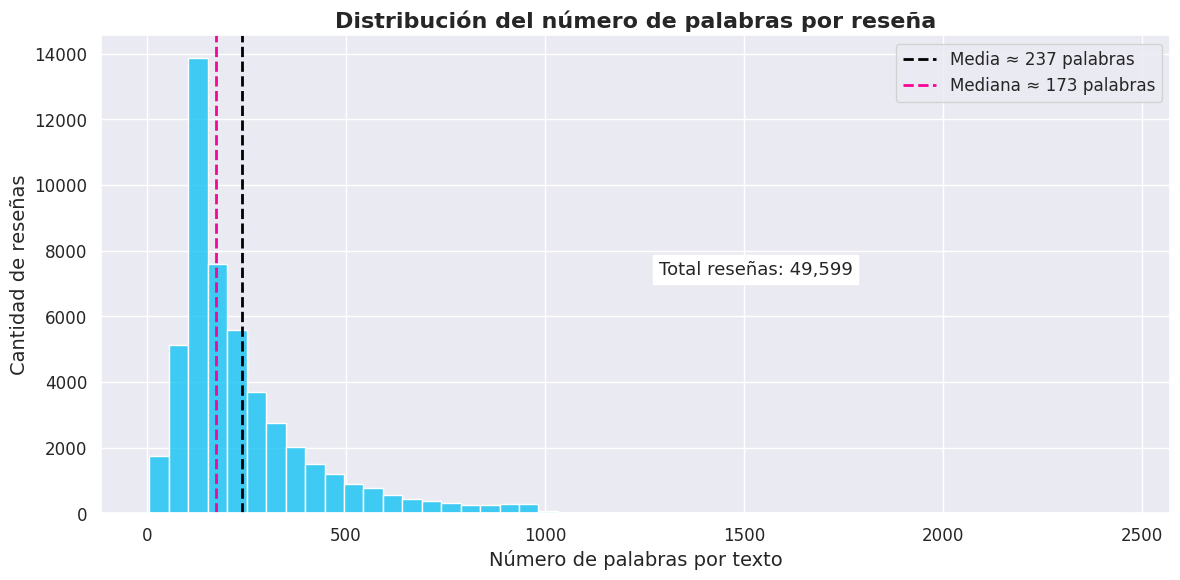

In [96]:
def distribucion_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.histplot(
      datos['n_palabras'],
      bins = 50,
      color = color_primario
      )

  plt.title(
      "Distribución del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  plt.ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  plt.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  plt.text(
      0.50 * plt.xlim()[1],
      0.50 * plt.ylim()[1],
      f"Total reseñas: {len(datos):,}",
      fontsize=13,
      bbox=dict(facecolor="white")
  )

  plt.legend() # Muestra la leyenda
  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña()

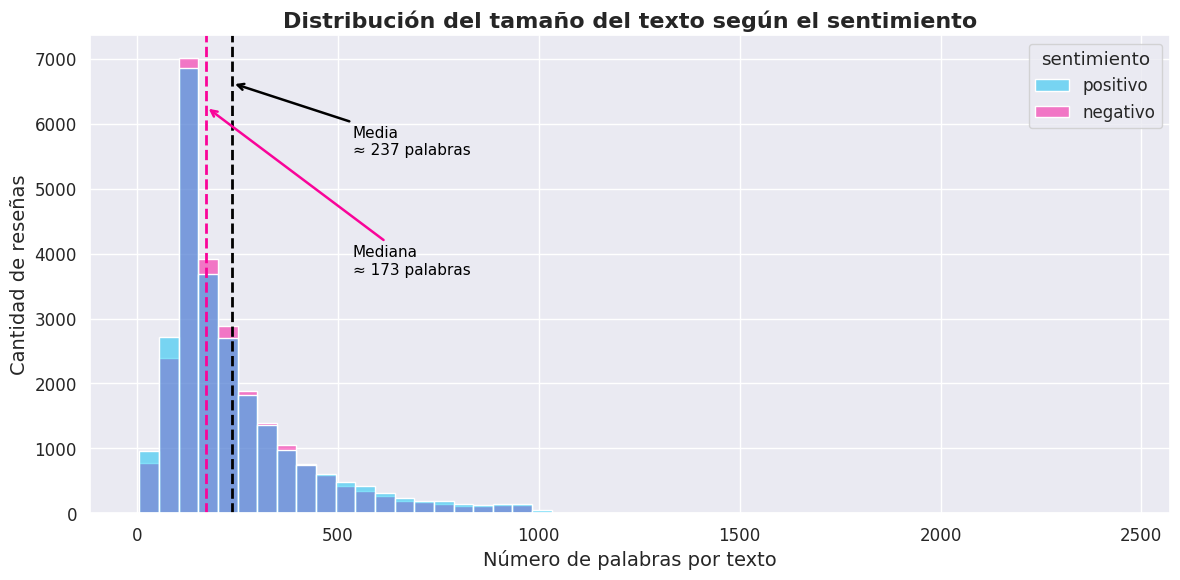

In [97]:
def distribucion_numero_palabras_por_reseña_por_sentimiento():
  fig, ax = plt.subplots(figsize=(12,6))

  sns.histplot(
      data = datos,
      x = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario],
      bins=50
  )

  ax.set_title(
      "Distribución del tamaño del texto según el sentimiento",
      fontsize = 16,
      fontweight = "bold"
  )

  ax.set_xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  ax.set_ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  ax.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  ax.axvline(
      mediana,
      color = color_secundario,
      linestyle = "--",
      linewidth = 2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  ax.annotate(
      f"Media\n≈ {media:.0f} palabras",
      xy = (media, ax.get_ylim()[1] * 0.9),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.75),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'black',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  texto_moda = ('Mediana')
  ax.annotate(
      f"Mediana\n≈ {mediana:.0f} palabras",
        xy = (mediana, ax.get_ylim()[1] * 0.85),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.50),
      arrowprops = dict(
            arrowstyle = "->",
            color = color_secundario,
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña_por_sentimiento()

#### Boxplot

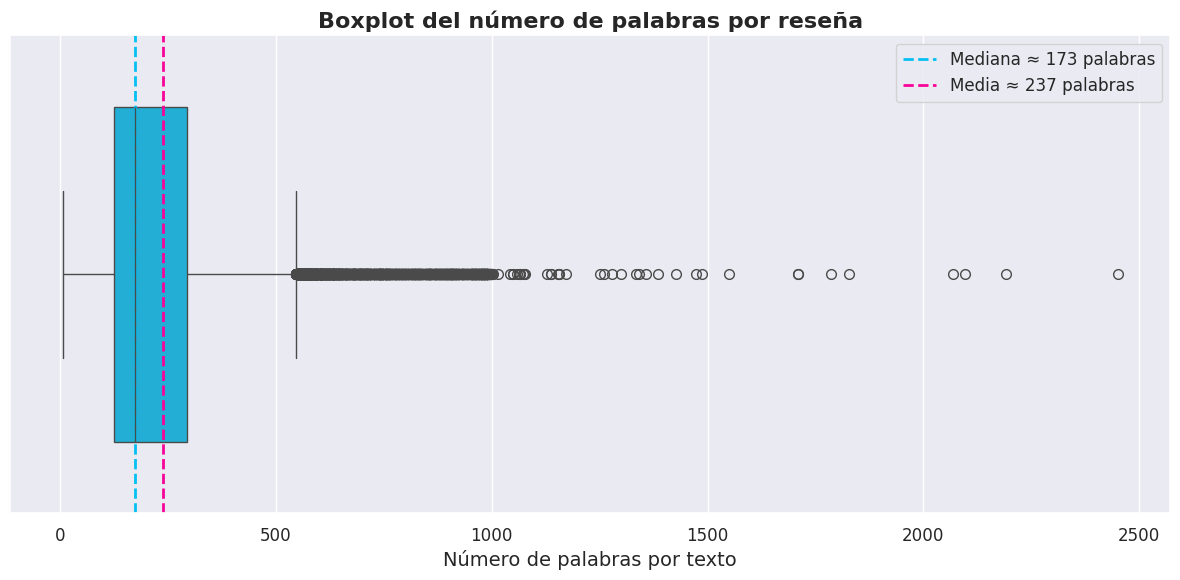

In [98]:
def boxplot_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.boxplot(
      x = datos['n_palabras'],
      color = color_primario,
      width = 0.7, # Tamaño del boxplot
      fliersize = 7, # Tamaño de los puntos atípicos
  )

  plt.title(
      "Boxplot del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_primario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )
  # Línea de referencia: media
  media = datos['n_palabras'].mean()
  plt.axvline(
      media,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Media ≈ {media:.0f} palabras"
  )


  plt.legend()
  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña()

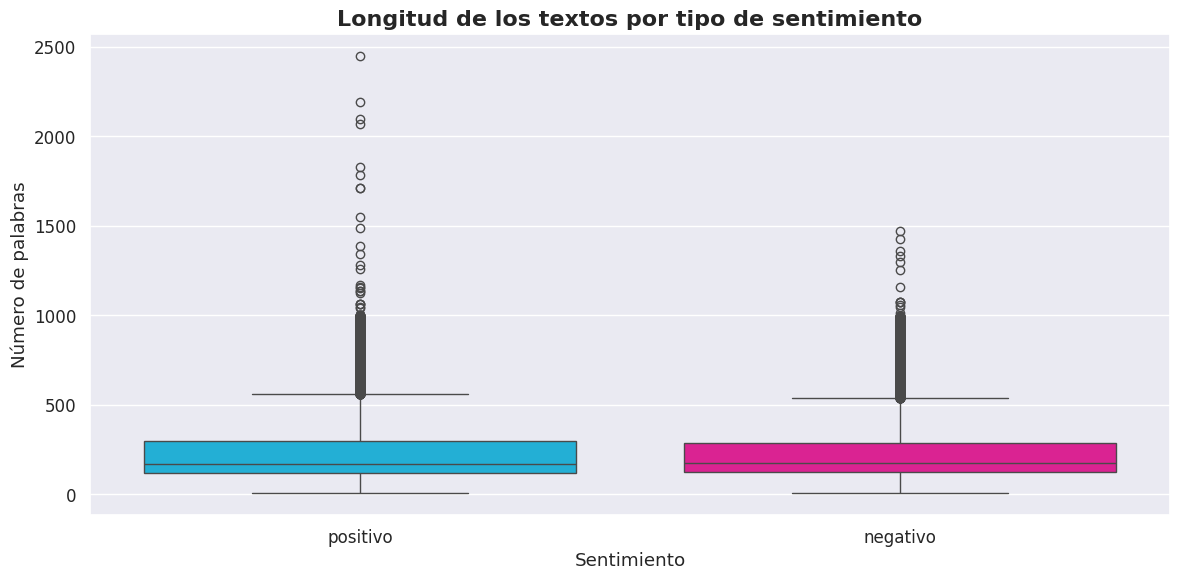

In [99]:
def boxplot_numero_palabras_por_reseña_por_sentimiento():
  plt.figure(figsize=(12,6))

  sns.boxplot(
      data = datos,
      x='sentimiento',
      y = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario]
  )

  plt.title(
      "Longitud de los textos por tipo de sentimiento",
      fontsize=16,
      fontweight="bold"
      )

  plt.xlabel("Sentimiento")

  plt.ylabel("Número de palabras")

  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña_por_sentimiento()

### **Conclusion**

#### **Conclusiones sobre la calidad de los datos**

* El conjunto de datos presenta algunos registros duplicados pero pocos comparados a la cantidad de datos, lo que indica una buena calidad inicial, además de que con la limpieza se eliminan para evitar sesgos por repetición de observaciones durante el entrenamiento del modelo.

* Las columnas cuentan con tipos de datos adecuados para el análisis, permitiendo trabajar correctamente con texto y variables categóricas.

#### **Conclusiones sobre la longitud de los textos**

- La longitud de las reseñas presenta alta variabilidad, con una media aproximada de 237 palabras y valores extremos que alcanzan más de 2400 palabras.

- La diferencia entre media y mediana indica una distribución sesgada a la derecha, confirmada por la presencia de múltiples outliers visibles en el boxplot.

- La mayoría de los textos se concentra en rangos bajos y medios de longitud, mientras que un pequeño porcentaje de reseñas muy extensas genera una cola larga en la distribución.

#### **Conclusiones sobre el idioma de los datos**

- Se detectó la presencia de reseñas en más de un idioma (español e inglés) dentro de la columna utilizada para el entrenamiento.

- Esto introduce un posible ruido lingüístico, ya que TF-IDF tratará palabras de ambos idiomas como parte del mismo vocabulario.

#### **Conclusión general del EDA**

El análisis exploratorio confirma que el conjunto de datos es apto para entrenar un modelo de análisis de sentimiento, cumpliendo con los requisitos del MVP propuesto.

Si bien existen desafíos como la alta variabilidad en la longitud de los textos y la presencia de múltiples idiomas, estos no impiden la construcción de un modelo inicial basado en TF-IDF y regresión logística.

El EDA permite identificar claramente oportunidades de mejora que pueden abordarse en iteraciones futuras, alineándose con el enfoque incremental esperado.

## <font color=#05C0F3>**Limpieza de datos**</font>

### **Tratamiento de Valores Nulos e Inconsistencias**

#### Conteo de valores nulos

In [100]:
datos.isnull().sum()

,0
review_es,0
sentimiento,0
n_palabras,0


No hay valores nulos en ninguna columna

### **Limpieza y Normalización del Texto**

#### Eliminar reseñas en inglés

In [101]:
def detectar_idioma(texto):
    try:
        return detect(texto) #Se usa la biblioteca langdetect
    except:
        return "desconocido"

In [102]:
datos.shape

(49599, 3)

In [103]:
#Columna con el idioma de la reseña (El procesamiento tardará)
datos['idioma_detectado'] = datos['review_es'].apply(detectar_idioma)

In [104]:
datos_limpios = datos[datos['idioma_detectado'] == 'es'].copy() #Solo guarda los datos en español

In [105]:
filas_originales = len(datos)
filas_limpias = len(datos_limpios)
print(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")

Se eliminaron 1816 filas que no estaban en español


In [106]:
datos = datos_limpios

In [107]:
datos.shape

(47783, 4)

#### Verificar la distribución de la columna objetivo (Sentimiento)

In [108]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,23935
negativo,23848


In [109]:
print("\nEstadísticas de longitud antes del balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud antes del balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23848.0  227.798390  157.361661   6.0  125.0  172.0  284.0  998.0
positivo     23935.0  230.686693  166.550784  10.0  122.0  170.0  290.0  955.0


#### Eliminar las reseñas más grandes (partes del sesgo) para mantener el equilibrio en el número de reseñas de ambos sentimientos

In [110]:
datos_pos = datos[datos['sentimiento'] == 'positivo'].copy()
datos_neg = datos[datos['sentimiento'] == 'negativo'].copy()

In [111]:
diferencia = len(datos_pos) - len(datos_neg)
print(f"Hay {diferencia} reseñas positivas extras")

Hay 87 reseñas positivas extras


In [112]:
datos_pos_balanceado = datos_pos.sort_values(by='n_palabras', ascending=False).iloc[diferencia:]
len(datos_pos_balanceado)

23848

In [113]:
datos_equilibrados = pd.concat([datos_pos_balanceado, datos_neg])

In [114]:
datos = shuffle(datos_equilibrados, random_state=42).reset_index(drop=True)

In [115]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,23848
negativo,23848


In [116]:
print("\nEstadísticas de longitud tras el balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud tras el balanceo:
               count        mean         std   min    25%    50%     75%  \
sentimiento                                                                
negativo     23848.0  227.798390  157.361661   6.0  125.0  172.0  284.00   
positivo     23848.0  228.215951  161.739488  10.0  121.0  169.0  288.25   

               max  
sentimiento         
negativo     998.0  
positivo     882.0  


#### Estandarización a minúsculas

In [123]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado,review_es_limpio
0,¡En total contraste con las opiniones de la ot...,positivo,142,es,¡en total contraste con las opiniones de la ot...
1,¿No hay nadie más cansado de ese viejo cliché ...,negativo,775,es,¿no hay nadie más cansado de ese viejo cliché ...
2,Si el escritor / director está leyendo esto (y...,negativo,89,es,si el escritor / director está leyendo esto (y...
3,Después de ver la revuelta de los zombies prot...,negativo,274,es,después de ver la revuelta de los zombies prot...
4,"Un novelista francés, disgustado por las amiga...",positivo,532,es,"un novelista francés, disgustado por las amiga..."
...,...,...,...,...,...
47691,"""Pecker"" demuestra que las aguas no tienen int...",positivo,179,es,"""pecker"" demuestra que las aguas no tienen int..."
47692,Playmania es extremadamente aburrido.Esta es l...,negativo,157,es,playmania es extremadamente aburrido.esta es l...
47693,"Un amigo mío, que es aún más en las películas ...",negativo,205,es,"un amigo mío, que es aún más en las películas ..."
47694,"Admito que nunca he visto ""Esperando a Gfffman...",positivo,636,es,"admito que nunca he visto ""esperando a gfffman..."


In [124]:
datos['review_es_limpio'] = datos['review_es'].str.lower()

In [125]:
datos['review_es_limpio']

,review_es_limpio
0,¡en total contraste con las opiniones de la ot...
1,¿no hay nadie más cansado de ese viejo cliché ...
2,si el escritor / director está leyendo esto (y...
3,después de ver la revuelta de los zombies prot...
4,"un novelista francés, disgustado por las amiga..."
...,...
47691,"""pecker"" demuestra que las aguas no tienen int..."
47692,playmania es extremadamente aburrido.esta es l...
47693,"un amigo mío, que es aún más en las películas ..."
47694,"admito que nunca he visto ""esperando a gfffman..."


#### Eliminación de caracteres especiales y números

Se usa regex (expresiones regulares) para remover símbolos, números o puntuación, lo cual es esencial para el procesamiento de texto

In [126]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)


In [128]:
display(datos['review_es_limpio'])

,review_es_limpio
0,en total contraste con las opiniones de la otr...
1,no hay nadie más cansado de ese viejo cliché d...
2,si el escritor director está leyendo esto y m...
3,después de ver la revuelta de los zombies prot...
4,un novelista francés disgustado por las amigas...
...,...
47691,pecker demuestra que las aguas no tienen inten...
47692,playmania es extremadamente aburridoesta es la...
47693,un amigo mío que es aún más en las películas d...
47694,admito que nunca he visto esperando a gffman l...


`[^a-záéíóúñü\s]`

Significa:
  Cualquier carácter que NO sea:
  - letras minúsculas
  - letras con tilde
  - ñ, ü
  - espacios

In [127]:
# Reduce repeticiones excesivas de caracteres:
# Ej: "bueeeno" → "bueeno", "holaaaa" → "holaa"
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(
    r'(.)\1{2,}', r'\1\1', regex=True
)

Se decidió normalizar las secuencias de un mismo carácter repetido
3 o más veces, reduciéndolas a un máximo de 2 repeticiones.

Esta decisión permite:
- Reducir la variabilidad innecesaria del vocabulario
- Conservar parte de la intención emocional del texto
- Mejorar la calidad del texto para tareas de NLP como análisis de sentimiento

La normalización de caracteres repetidos se aplica para evitar que variaciones
ortográficas no semánticas afecten la tokenización y el desempeño del modelo.
Se conserva un máximo de dos repeticiones para no eliminar completamente
el énfasis expresivo del lenguaje informal.

#### Eliminar espacios múltiples

In [129]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [130]:
display(datos['review_es_limpio'])

,review_es_limpio
0,en total contraste con las opiniones de la otr...
1,no hay nadie más cansado de ese viejo cliché d...
2,si el escritor director está leyendo esto y me...
3,después de ver la revuelta de los zombies prot...
4,un novelista francés disgustado por las amigas...
...,...
47691,pecker demuestra que las aguas no tienen inten...
47692,playmania es extremadamente aburridoesta es la...
47693,un amigo mío que es aún más en las películas d...
47694,admito que nunca he visto esperando a gffman l...


## <font color=#05C0F3>**Transformación de Características (Feature Engineering)**</font>

In [131]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado,review_es_limpio
0,¡En total contraste con las opiniones de la ot...,positivo,142,es,en total contraste con las opiniones de la otr...
1,¿No hay nadie más cansado de ese viejo cliché ...,negativo,775,es,no hay nadie más cansado de ese viejo cliché d...
2,Si el escritor / director está leyendo esto (y...,negativo,89,es,si el escritor director está leyendo esto y me...
3,Después de ver la revuelta de los zombies prot...,negativo,274,es,después de ver la revuelta de los zombies prot...
4,"Un novelista francés, disgustado por las amiga...",positivo,532,es,un novelista francés disgustado por las amigas...
...,...,...,...,...,...
47691,"""Pecker"" demuestra que las aguas no tienen int...",positivo,179,es,pecker demuestra que las aguas no tienen inten...
47692,Playmania es extremadamente aburrido.Esta es l...,negativo,157,es,playmania es extremadamente aburridoesta es la...
47693,"Un amigo mío, que es aún más en las películas ...",negativo,205,es,un amigo mío que es aún más en las películas d...
47694,"Admito que nunca he visto ""Esperando a Gfffman...",positivo,636,es,admito que nunca he visto esperando a gffman l...


### **Definición de variables de entrada (X) y salida (y)**

In [132]:
X = datos['review_es_limpio']

In [133]:
display(X)

,review_es_limpio
0,en total contraste con las opiniones de la otr...
1,no hay nadie más cansado de ese viejo cliché d...
2,si el escritor director está leyendo esto y me...
3,después de ver la revuelta de los zombies prot...
4,un novelista francés disgustado por las amigas...
...,...
47691,pecker demuestra que las aguas no tienen inten...
47692,playmania es extremadamente aburridoesta es la...
47693,un amigo mío que es aún más en las películas d...
47694,admito que nunca he visto esperando a gffman l...


In [134]:
y = datos['sentimiento'].map({
    'negativo': 0,
    'positivo': 1
})

In [135]:
display(y)

,sentimiento
0,1
1,0
2,0
3,0
4,1
...,...
47691,1
47692,0
47693,0
47694,1


### **División de datos en conjuntos de entrenamiento y prueba**

In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

### **Inicialización del Vectorizador TF-IDF**

El TF-IDF (Term Frequency-Inverse Document Frequency) es la técnica clave que transforma el texto en números, mostrando qué palabras son más importantes para cada documento/reseña.

In [139]:
stopwords_es = stopwords.words('spanish')

In [140]:
negaciones = {'no', 'ni', 'sin', 'pero', 'nunca', 'jamás'}

In [141]:
stopwords_personalizadas = list(set(stopwords_es) - negaciones)

In [151]:
vectorizador = TfidfVectorizer(
    stop_words = stopwords_personalizadas,
    ngram_range = (1, 2),
    max_features = 5000,
    min_df = 5,
    max_df = 0.9,
    sublinear_tf = True
)

stop_words=stopwords_personalizadas
Se usan stopwords en español, pero se conservan negaciones como “no”, “pero”, “sin” para no perder información semántica clave en el sentimiento.

- g`ram_range=(1, 2)`
Incluye unigramas y bigramas para capturar tanto palabras individuales como expresiones relevantes (“no me gustó”, “muy buena”).

- `max_features=5000`
Limita el vocabulario a los términos más informativos, logrando un buen balance entre rendimiento y costo computacional.

- `min_df=5`
Elimina términos muy poco frecuentes, reduciendo ruido y aumentando la estabilidad del modelo.

- `max_df=0.9`
Excluye palabras demasiado comunes que no ayudan a diferenciar el sentimiento.

- `sublinear_tf=True`
Reduce el impacto de repeticiones excesivas de una palabra, evitando que dominen la representación del texto.

### **Ajuste (fit) y Transformación (transform) del conjunto de entrenamiento**

In [152]:
X_train_tfidf  = vectorizador.fit_transform(X_train)

In [153]:
display(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2655009 stored elements and shape (33387, 5000)>

### **Transformación del conjunto de prueba**

In [154]:
X_test_tfidf = vectorizador.transform(X_test)

In [155]:
display(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1135563 stored elements and shape (14309, 5000)>

#### Dimension

In [156]:
X_train_tfidf.shape

(33387, 5000)

In [157]:
X_test_tfidf.shape

(14309, 5000)

## <font color=#05C0F3>**Modelado y Evaluación**</font>

El modelo recomendado es la Regresión Logística, una técnica de clasificación supervisada simple y efectiva para este tipo de problemas.

### **Entrenamiento**

#### Inicialización del modelo de clasificación (Regresión Logística)

In [159]:
modelo = LogisticRegression(
    random_state = 42,
    max_iter = 1000,
    class_weight = 'balanced',
    solver = 'liblinear'
    )

Se utiliza Regresión Logística para la clasificación de sentimiento debido a su estabilidad, buen desempeño con texto vectorizado mediante TF-IDF y capacidad de devolver probabilidades, requisito clave para la API.


- `max_iter=1000`
Aumenta el número máximo de iteraciones para asegurar que el modelo tenga suficiente tiempo para converger correctamente, especialmente al trabajar con un gran número de características generadas por TF-IDF.

- `class_weight='balanced'`
Ajusta automáticamente el peso de cada clase, haciendo el modelo más robusto ante posibles desbalances y evitando sesgos en la predicción.

- `solver='liblinear'`
Selecciona un método de optimización estable y eficiente, especialmente adecuado para problemas de clasificación binaria con conjuntos de datos de tamaño medio y alta dimensionalidad.

#### Entrenamiento del modelo

In [160]:
modelo.fit(X_train_tfidf, y_train, )

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

#### Predicciones

In [161]:
y_pred = modelo.predict(X_test_tfidf)

In [162]:
y_proba = modelo.predict_proba(X_test_tfidf) # Obtiene las probabilidades, esencial para el contrato de la API

### **Evaluación del Desempeño**

#### Cálculo y presentación de métricas

In [163]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['negativo', 'positivo']))


Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.88      0.86      0.87      7155
    positivo       0.86      0.88      0.87      7154

    accuracy                           0.87     14309
   macro avg       0.87      0.87      0.87     14309
weighted avg       0.87      0.87      0.87     14309



#### Obtener palabras más significativas para cada sentimiento

In [164]:
palabras = vectorizador.get_feature_names_out()
coefs = modelo.coef_.flatten()
datos_palabras = pd.DataFrame({'palabra': palabras, 'coeficiente': coefs})

In [165]:
top_pos = datos_palabras.nlargest(10, 'coeficiente')
top_neg = datos_palabras.nsmallest(10, 'coeficiente')
top_palabras = pd.concat([top_pos, top_neg])

/tmp/ipython-input-3743336128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')


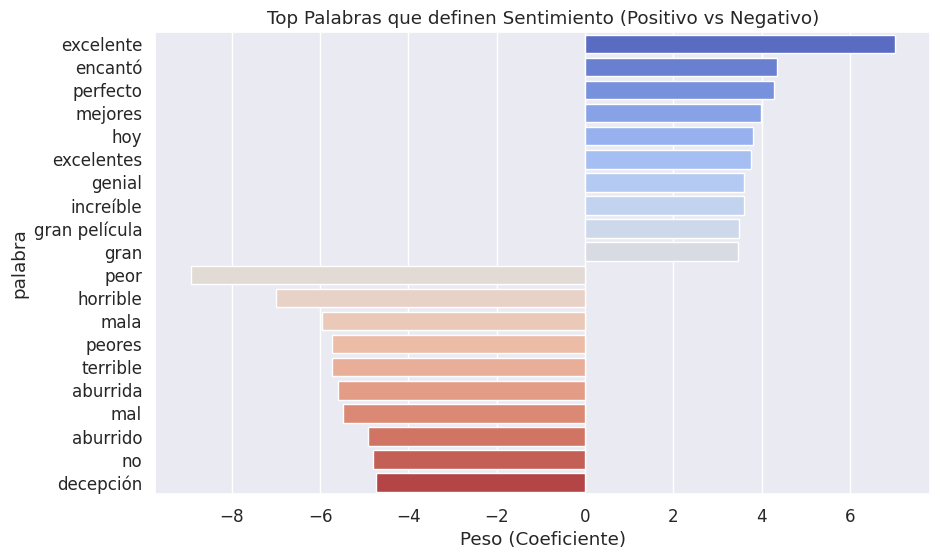

In [166]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')
plt.title('Top Palabras que definen Sentimiento (Positivo vs Negativo)')
plt.xlabel('Peso (Coeficiente)')
plt.show()

#### Análisis de Errores


In [ ]:
datos_test = X_test.to_frame(name='review').copy()
datos_test['real'] = y_test
datos_test['prediccion'] = y_pred

In [ ]:
errores = datos_test[datos_test['real'] != datos_test['prediccion']]
print(f"Total de errores: {len(errores)} de {len(datos_test)}")

Total de errores: 1890 de 14310


In [ ]:
errores.sample(10)

,review,real,prediccion
1912,la leyenda de dragoon es uno de esos juegos po...,1,0
41767,vi el messiah hace unos meses y no pudimos ver...,1,0
11852,fue genial ver algunas de mis estrellas favori...,0,1
4047,el problema con otros actores fundidos en el r...,1,0
24654,la película la puerta del cielo fue una buena ...,0,1
25296,en las montañas de japón el joven artista de s...,0,1
15999,el agua muestra la difícil situación de las vi...,0,1
41138,no voy a decir la historia de la película como...,0,1
14971,entonces qué constituye una verdadera película...,1,0
4108,como parte de la celebración del lanzamiento d...,1,0


##### Falsos Positivos (Eran negativos y se clasificaron como positivos)

Son los errores más importantes y que se tienen que destacar, dado que en los requisitos (y en general para cualquier modelo de atención al cliente) es peor ignorar los comentarios negativos y no darles atención (falsos positivos)

In [ ]:
for i, row in errores[errores['prediccion'] == 1].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: todavía tengo que leer una revisión profesional negativa de esta películasupongo que debo haber perdido algoel comienzo es intrigante los tres personajes principales se reúnen a altas horas de la noche en una barra de otro modo vacía y entre sí con historias inventadasesa es la mejor partedespués de...
Real: 0 | Pred: 1

Review: otra película que hace peor la historia de los chicos de la playa de lo que esrecuerdo especialmente la escena cuando brian dice que es para dejar de fumar y los otros niños lo llaman traidorno sucedí así y al igual que la película indica al principio es que algunas escenas se requieren sobrepasadas...
Real: 0 | Pred: 1

Review: esta película es sobre una brecha que existe entre el mundo real y el mundo de los muertos hay un montón de mumbojumbo sobre internet es decir si instala un programa en la computadora se ve a la gente muerta al igual que si juega una cinta de video morirá en ringu francamente la mayoría de esto pare...
Real: 0 | Pred: 1



##### Falsos Negativos (Eran positivos y se clasificaron como negativos)

In [ ]:
for i, row in errores[errores['prediccion'] == 0].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: esto no es una película seria y no pretende ser pero no es tan malo como algunas de sus críticas su título y los primeros diez minutos le llevan a esperar la parcela es muy tonta pero esto se suma a ladiversión y entusiasmo alegre que corre por la películalos personajes se desempeñan con simpatía y ...
Real: 1 | Pred: 0

Review: oceans if you robes cincuenta millones de dólares te encontrarán alan rickman como hans gruber muere duro este adagio ciertamente suena verdadero en esta secuela terry benedicto ha sido informado de que danny ocean y sus compadres fueron los que lo derribaron y ahora lo quiere de nuevo la pandilla d...
Real: 1 | Pred: 0

Review: por alguna razón siempre disfruto de las películas que las personas odian cuando realmente no creo que sean tan malas y esta es una de esas películas en el caso de esta película creo que es demasiado criticado demasiado realmente no es tan malo de una película en absoluto de hecho creo que esta es u...
Real: 1 | Pred: 0



#### Matriz de confusión


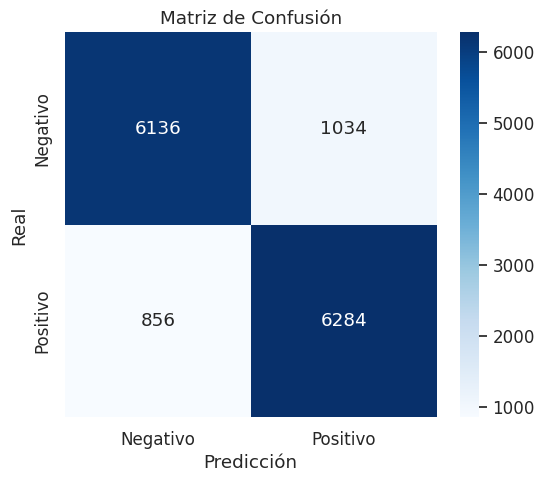

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.show()

La matriz de confusión muestra como hay un poco más de falsos positivos que de falsos negativos, para este ejemplo, nos importa mucho más las reseñas negativas para poder atender el disgusto de los clientes. Por lo tanto, es preferible tener menos falsos positivos (reseñas negativas tomadas como positivas) aunque eso conlleve a tener un poco más de falsos negativos.

#### Obtener el mejor umbral para reducir falsos positivos

In [ ]:
pipeline_test = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words=stopwords_es,
        ngram_range=(1, 2),
        max_features=5000,
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(random_state=42))
])

pipeline_test.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['de', 'la', 'que', 'el', 'en', 'y',
                                             'a', 'los', 'del', 'se', 'las',
                                             'por', 'un', 'para', 'con', 'no',
                                             'una', 'su', 'al', 'lo', 'como',
                                             'más', 'pero', 'sus', 'le', 'ya',
                                             'o', 'este', 'sí', 'porque', ...])),
                ('clf', LogisticRegression(random_state=42))])

In [ ]:
probs = pipeline_test.predict_proba(X_test)[:, 1]

In [ ]:
def probar_umbral(umbral):
    # Si la probabilidad es mayor al umbral, es 'positivo', si no 'negativo'
    preds_ajustadas = np.where(probs > umbral, 1, 0)

    # Generar matriz de confusión con el nuevo umbral
    cm = confusion_matrix(y_test, preds_ajustadas, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return fp, fn, cm

In [ ]:
umbrales = [0.5, 0.6, 0.63, 0.64, 0.645, 0.65, 0.655, 0.66, 0.67, 0.7, 0.8]

In [ ]:
print(f"{'Umbral':<10} {'Falsos Positivos (Riesgo)':<25} {'Falsos Negativos (Revisión extra)'}")
print("-" * 70)
for u in umbrales:
    fp, fn, _ = probar_umbral(u)
    print(f"{u:<10} {fp:<25} {fn}")

Umbral     Falsos Positivos (Riesgo) Falsos Negativos (Revisión extra)
----------------------------------------------------------------------
0.5        843                       675
0.6        527                       1080
0.63       451                       1251
0.64       415                       1300
0.645      399                       1331
0.65       381                       1358
0.655      372                       1387
0.66       360                       1414
0.67       336                       1489
0.7        273                       1695
0.8        127                       2629


#### Usando el mejor umbral

Al tener un umbral más alto, es más estricto para que el modelo clasifique una reseña como positiva, lo que reduce significativamente la probabilidad de no atender una reseña negativa.

El mejor umbral fue de ***0.65***, con lo que se reducen la cantidad de falsos positivos, pero sin llevar a una enorme cantidad de falsos negativos.
Considerando los requisitos del proyecto, es priorizable detectar correctamente las reseñas negativas que las positivas.

In [ ]:
mejor_umbral = 0.65
y_pred_final = np.where(probs > mejor_umbral, 1, 0)


--- Matriz de Confusión con Umbral 0.65 ---


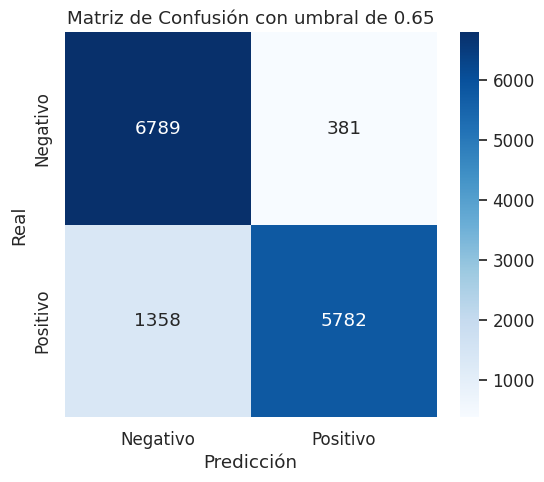

In [ ]:
print(f"\n--- Matriz de Confusión con Umbral {mejor_umbral} ---")
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión con umbral de 0.65')
plt.show()

## <font color=#05C0F3>**Serialización e Integración con Back-End (Java)**</font>

Esta es la fase de entrega del artefacto. El modelo entrenado y, crucialmente, el vectorizador TF-IDF (necesario para transformar el texto de entrada que envía el BE), deben ser guardados en un formato binario (joblib o pickle)

### **Definición del Pipeline de Predicción**

Para garantizar que el Back-End pueda hacer predicciones correctas, es mejor serializar el Pipeline completo: Vectorizador + Modelo.

In [ ]:
pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words=stopwords_es,
        ngram_range=(1, 2),
        max_features=5000,
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(random_state=42))
])

### **Reentrenar el pipeline con X y Y**

In [ ]:
pipeline_final.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['de', 'la', 'que', 'el', 'en', 'y',
                                             'a', 'los', 'del', 'se', 'las',
                                             'por', 'un', 'para', 'con', 'no',
                                             'una', 'su', 'al', 'lo', 'como',
                                             'más', 'pero', 'sus', 'le', 'ya',
                                             'o', 'este', 'sí', 'porque', ...])),
                ('clf', LogisticRegression(random_state=42))])

### **Serialización**

In [ ]:
joblib.dump(pipeline_final, 'sentiment_model_1.2.joblib')

['sentiment_model_1.2.joblib']

### **Contrato de Integración y Pruebas Locales**

Prueba en Python para simular la predicción, mostrando cómo el modelo toma un texto sin procesar y genera una predicción con probabilidad.

In [ ]:
# Simulación de predicción
texto_ejemplo = "La interfaz es confusa y me hicieron esperar mucho."

In [ ]:
pred_sentimiento = pipeline_final.predict([texto_ejemplo])

In [ ]:
probabilidades = pipeline_final.predict_proba([texto_ejemplo])

In [ ]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [ ]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: [0], Probabilidad: 0.63


#### **FastAPI**

**El siguiente codigo es de prueba y va en el archivo del proyecto en github**

~~~
# Instalaciones
# pip install fastapi uvicorn joblib scikit-learn nltk # Se ejecuta en consola

# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

# Cargar el modelo (UNA SOLA VEZ)
app = FastAPI(title="Sentiment Analysis API")

modelo = joblib.load("sentiment_model_1.1.joblib")

# Contrato de entrada (request)
class SentimentRequest(BaseModel):
    text: str
#    {
#        text: "La película fue excelente"
#    }

# Contrato de salida (response)
class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

# Endpoint principal /sentiment
@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):

    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento"
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

# Ejecutar el servidor
# uvicorn app:app --reload # Se ejecuta en consola

POST http://localhost:8000/sentiment
Content-Type: application/json
# Eso va en:
# Postman
# Swagger
# README
# documentación

# Formato
{
  "text": "La interfaz es confusa y lenta"
}
{
  "prevision": "Negativo",
  "probabilidad": 0.92
}

~~~

**Comentario Fast API (Prueba)** **NO EJECUTAR**

**El archivo de Git tendría que tener esta estrucura**

- Modelo_hackathon.ipynb
- app.py
- requirements.txt
- sentiment_model.joblib

### Archivo requirements.txt
### Dentro del archivo .txt el siguiente texto:

- fastapi
- uvicorn
- joblib
- scikit-learn
- nltk
- numpy

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): pip install -r requirements.txt
- 2. Encender el servidor: uvicorn app:app --reload

### Arhivo ipynb, Modelo_hackathon.ipynb
El archivo .ipynb crea el archivo (sentiment_model.joblib)
Descargar el archivo .joblib y colocarlo dentro de la estructura del Git

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): `pip install -r requirements.txt`
- 2. Encender el servidor: `uvicorn app:app --reload`